# Evaluating Peak-to-Gene Predictions with Experimental Validation

This tutorial demonstrates how to evaluate and compare peak-to-gene predictions from different computational methods using experimental validation data. We'll use Hi-C and ChIA-PET datasets as ground truth to assess the quality of predicted regulatory relationships.

## Overview

Computational prediction of peak-to-gene links is a fundamental challenge in single-cell genomics. To objectively compare different methods, we need experimental validation datasets that capture true regulatory relationships. This tutorial shows how to:

1. **Load experimental validation data** (Hi-C and ChIA-PET)
2. **Compare computational predictions** against experimental evidence
3. **Calculate enrichment metrics** to quantify method performance
4. **Visualize comparative results** across multiple methods

## Experimental Validation Datasets

### Hi-C Data:
- **Technology**: Chromosome conformation capture (3C-based)
- **Information**: Genome-wide chromatin interactions
- **Resolution**: Identifies both promoter-enhancer and structural interactions
- **Strength**: Comprehensive, unbiased interaction mapping

### ChIA-PET Data:
- **Technology**: Chromatin interaction analysis by paired-end tag sequencing
- **Information**: Protein-mediated chromatin interactions
- **Resolution**: Higher specificity for transcription factor-mediated loops
- **Strength**: Identifies functional regulatory interactions

## Evaluation Strategy:

We use **odds ratio analysis** to measure how well each method's top predictions are enriched for experimentally validated interactions compared to random expectations. Higher odds ratios indicate better performance in identifying true regulatory relationships.

In [30]:
suppressMessages(library(cicero))
suppressMessages(library(ggplot2))
suppressMessages(library(cowplot))
suppressMessages(library(gridExtra))
suppressMessages(library(dplyr))

## Setup Input Directory

Define the path to processed peak-to-gene predictions from the previous tutorial (05_process_p2g).

In [31]:
in_dir <- "./05_process_p2g"

## Load Experimental Validation Data

Import Hi-C and ChIA-PET datasets that serve as ground truth for evaluating computational peak-to-gene predictions.

### Hi-C Data (ENCFF256ZMD):
- **Source**: ENCODE K562 Hi-C experiment
- **Technology**: Genome-wide chromatin interaction mapping
- **Format**: BEDPE (paired genomic intervals)
- **Coverage**: Comprehensive interaction landscape

### ChIA-PET Data (ENCFF607PZX):  
- **Source**: ENCODE K562 ChIA-PET experiment
- **Technology**: Protein-mediated chromatin interactions
- **Format**: BEDPE (paired genomic intervals)
- **Specificity**: Transcription factor-mediated loops

Both datasets are processed to create standardized coordinate formats matching our computational predictions.

In [32]:
# read Hi-C and ChIA-PET data
df_hic <- read.table("../../../../data/K562_HiC/ENCFF256ZMD.bedpe", 
                       sep = "\t", 
                       header = FALSE,
                       stringsAsFactors = FALSE)
colnames(df_hic)[1:6] <- c("chr1", "start1", "end1",
                            "chr2", "start2", "end2")

df_hic$Peak1 <- paste(df_hic$chr1, df_hic$start1, df_hic$end1, sep = "_")
df_hic$Peak2 <- paste(df_hic$chr2, df_hic$start2, df_hic$end2, sep = "_")
df_hic <- df_hic[c("Peak1", "Peak2")]

df_chiapet <- read.table("../../../../data/K562_ChIAPET/ENCFF607PZX.bedpe", 
                       sep = "\t", 
                       header = FALSE,
                       stringsAsFactors = FALSE)
colnames(df_chiapet)[1:6] <- c("chr1", "start1", "end1",
                            "chr2", "start2", "end2")
df_chiapet$Peak1 <- paste(df_chiapet$chr1, df_chiapet$start1, df_chiapet$end1, sep = "_")
df_chiapet$Peak2 <- paste(df_chiapet$chr2, df_chiapet$start2, df_chiapet$end2, sep = "_")
df_chiapet <- df_chiapet[c("Peak1", "Peak2")]

## Define Evaluation Function

Create a function to compute odds ratios that measure how well computational predictions are enriched for experimentally validated interactions.

### Methodology:
1. **Compare predictions with validation data** using genomic overlap (±100bp tolerance)
2. **Calculate baseline proportion** from top 50,000 predictions
3. **Compute odds ratios** for different prediction set sizes (5K to 50K)
4. **Return enrichment metrics** for performance assessment

### Key Metrics:
- **Proportion linked**: Fraction of predictions supported by experimental data
- **Odds ratio**: Enrichment relative to baseline expectation
- **Progressive evaluation**: Performance across different stringency levels

### Statistical Rationale:
Higher odds ratios indicate that a method's top predictions are more enriched for true regulatory relationships compared to random expectations. This provides an objective measure of method performance.

In [33]:
compute_ratio <- function(df_pred, df_true){
    prop_list <- list()
    ratio_list <- list()
    n_links_list <- list()

    df_pred$isLinked <- compare_connections(df_pred, df_true, maxgap=100)
    df_top_50k <- df_pred %>%
        arrange(desc(score)) %>%
        slice_head(n = 50000)

    odds_b = sum(df_top_50k$isLinked) / nrow(df_top_50k)

    for(top_n in c(5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000)){
        df_top <- df_pred %>%
            arrange(desc(score)) %>%
            slice_head(n = top_n)
        
        odds_a = sum(df_top$isLinked) / nrow(df_top)
        odds_ratio = odds_a / odds_b
        
        # Store results
        n_links_list <- append(n_links_list, top_n)
        prop_list <- append(prop_list, odds_a)
        ratio_list <- append(ratio_list, odds_ratio)
    }

    df_res <- data.frame(
        n_links = unlist(n_links_list),
        prop_linked = unlist(prop_list),
        odds_ratio = unlist(ratio_list)
    )

    return(df_res)
}

## Evaluate All Methods Against Validation Data

Systematically evaluate each computational method (Cell2Net, SCENT, SCARlink, Signac) against both experimental validation datasets (Hi-C and ChIA-PET).

### Process:
1. **Load predictions** from each method (processed in tutorial 05)
2. **Apply evaluation function** to compute odds ratios
3. **Compare against both datasets** for comprehensive assessment  
4. **Combine results** into unified dataframe for visualization
5. **Track method performance** across different prediction set sizes

### Output Structure:
- **n_links**: Number of top predictions evaluated
- **prop_linked**: Proportion supported by experimental data
- **odds_ratio**: Enrichment relative to baseline
- **method**: Computational approach name
- **data**: Validation dataset type (Hi-C or ChIA-PET)

In [34]:
df_final <- lapply(c("cell2net", "scent", "scarlink", "signac"), function(method) {
   df_pred <- read.csv(glue::glue("{in_dir}/{method}.csv"), row.names = 1)

   df_hic_res <- compute_ratio(df_pred, df_hic)
   df_chiapet_res <- compute_ratio(df_pred, df_chiapet)

   df_hic_res$method <- method
   df_chiapet_res$method <- method

   df_hic_res$data <- "Hi-C"
   df_chiapet_res$data <- "ChIA-PET"
   df <- rbind(df_hic_res, df_chiapet_res)

   return(df)
} ) %>%
    bind_rows()

Let's examine the structure of our evaluation results:

In [35]:
head(df_final)

,n_links,prop_linked,odds_ratio,method,data
,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,5000,0.05980000,1.874608,cell2net,Hi-C
2,10000,0.05340000,1.673981,cell2net,Hi-C
3,15000,0.04800000,1.504702,cell2net,Hi-C
4,20000,0.04440000,1.391850,cell2net,Hi-C
5,25000,0.04072000,1.276489,cell2net,Hi-C
6,30000,0.03743333,1.173459,cell2net,Hi-C


## Visualize Method Performance Comparison

Create comprehensive plots showing how each method performs against experimental validation data.

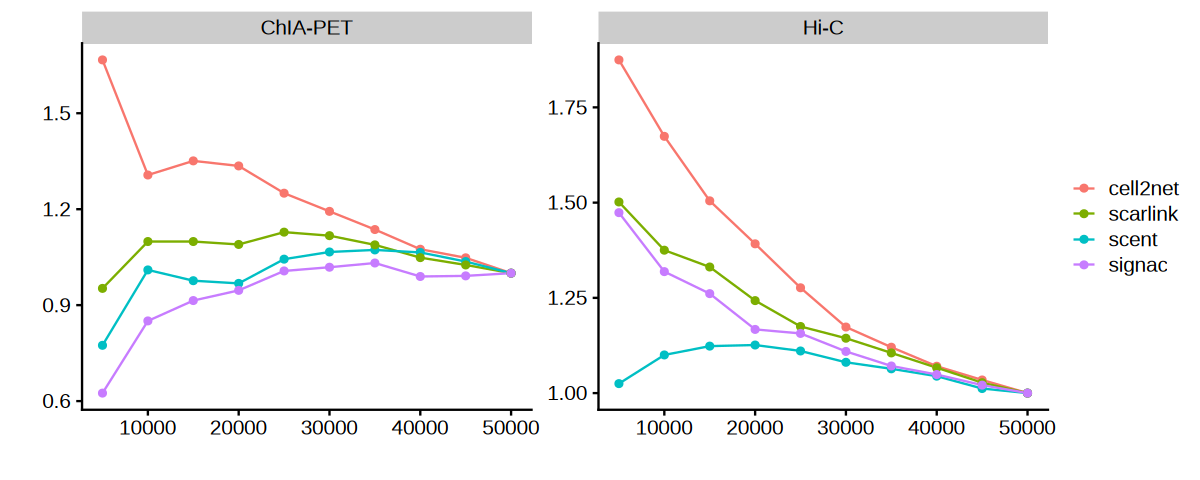

In [36]:
options(repr.plot.height = 4, repr.plot.width = 10)

p <- ggplot(data = df_final, aes(x = n_links, y = odds_ratio)) +
    geom_line(aes(color = method)) +
    geom_point(aes(color = method)) +
    facet_wrap(~data, scales = "free") +
    xlab("") + ylab("") +
    theme_cowplot() +
    theme(legend.title = element_blank())

print(p)